In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path("C:/Users/aleks/Documents/GitHub/asymmetric-catalysis-qspr-ml/Thia-Michael_regression/third_split/Kfold/substrate/no_chemberta_Kfold_Review_1/Results/ReviewerValidation/")
BOOTSTRAP_XLSX = Path(r"Thia-Michael_bootstrap.xlsx")
OUT_DIR = Path("validation_figures")
OUT_DIR.mkdir(exist_ok=True)

CV_FILE = DATA_DIR / "RS42_preselected_n7_preselected_False_DecisionTree_cv_fold_metrics.csv"
SHUFFLE_DIST_FILE = DATA_DIR / "RS42_preselected_n7_preselected_False_DecisionTree_target_shuffling_distribution.csv"
SHUFFLE_SUMMARY_FILE = DATA_DIR / "RS42_preselected_n7_preselected_False_DecisionTree_target_shuffling_summary.csv"

COLORS = {
    "navy": "#1F4E79",
    "blue": "#4C78A8",
    "red": "#B22222",
    "gray": "#6C757D",
    "light_gray": "#D9E2F3",
}

sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
})

for file_path in [CV_FILE, SHUFFLE_DIST_FILE, SHUFFLE_SUMMARY_FILE, BOOTSTRAP_XLSX]:
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

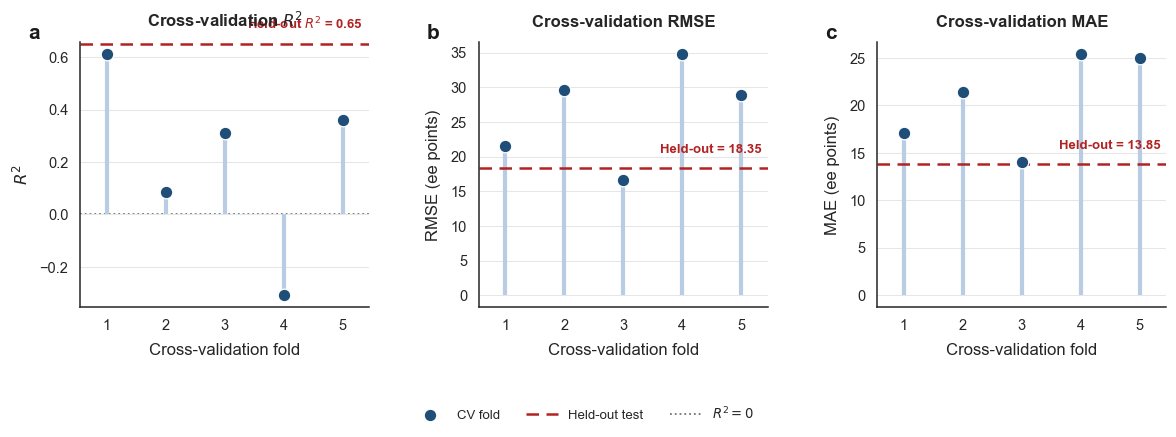

In [3]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# -------------------------
# Publication-style settings
# -------------------------
sns.set_theme(style="white", context="paper")

mpl.rcParams.update({
    "font.family": "Arial",          # Jeśli Arial nie jest dostępny, matplotlib użyje sans-serif
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 9.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "axes.linewidth": 1.1,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 4.5,
    "ytick.major.size": 4.5,
})

# -------------------------
# Input values
# -------------------------
HELDOUT_R2 = 0.65
HELDOUT_RMSE = 18.34598048619915
HELDOUT_MAE = 13.85

COLORS = {
    "fold": "#1F4E79",       # dark blue
    "stem": "#B8CDE3",       # pale blue
    "heldout": "#B22222",    # dark red
    "zero": "#6C757D",       # grey
    "text": "#1A1A1A",
}

cv = pd.read_csv(CV_FILE).sort_values("fold")

# -------------------------
# Figure
# -------------------------
fig, axes = plt.subplots(
    1,
    3,
    figsize=(12.0, 4.35),
    sharex=True,
)

plot_specs = [
    {
        "metric": "R2",
        "ylabel": r"$R^2$",
        "heldout": HELDOUT_R2,
        "panel": "a",
        "title": r"Cross-validation $R^2$",
        "baseline": 0.0,
    },
    {
        "metric": "RMSE",
        "ylabel": "RMSE (ee points)",
        "heldout": HELDOUT_RMSE,
        "panel": "b",
        "title": "Cross-validation RMSE",
        "baseline": None,
    },
    {
        "metric": "MAE",
        "ylabel": "MAE (ee points)",
        "heldout": HELDOUT_MAE,
        "panel": "c",
        "title": "Cross-validation MAE",
        "baseline": None,
    },
]

for ax, spec in zip(axes, plot_specs):
    metric = spec["metric"]
    heldout_value = spec["heldout"]

    # Pale stems make individual folds visible without visually overloading the panel.
    ax.vlines(
        x=cv["fold"],
        ymin=0,
        ymax=cv[metric],
        color=COLORS["stem"],
        linewidth=3.0,
        zorder=1,
    )

    # Individual CV-fold values.
    ax.scatter(
        cv["fold"],
        cv[metric],
        color=COLORS["fold"],
        edgecolor="white",
        linewidth=0.9,
        s=82,
        zorder=3,
        label="CV fold",
    )

    # Reference line for held-out test performance.
    ax.axhline(
        heldout_value,
        color=COLORS["heldout"],
        linestyle=(0, (5, 3)),
        linewidth=1.8,
        zorder=2,
        label="Held-out test",
    )

    # Only R2 has an interpretable null baseline at zero.
    if spec["baseline"] is not None:
        ax.axhline(
            spec["baseline"],
            color=COLORS["zero"],
            linestyle=":",
            linewidth=1.3,
            zorder=0,
            label=r"$R^2 = 0$",
        )

    # Panel label.
    ax.text(
        -0.18,
        1.07,
        spec["panel"],
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="top",
        ha="left",
        color=COLORS["text"],
    )

    # Panel title and labels.
    ax.set_title(spec["title"], pad=11, fontweight="bold")
    ax.set_xlabel("Cross-validation fold", labelpad=7)
    ax.set_ylabel(spec["ylabel"], labelpad=7)

    # Axis formatting.
    ax.set_xticks(cv["fold"])
    ax.set_xlim(0.55, 5.45)
    ax.tick_params(direction="out", width=1.0, length=4.5, pad=4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Subtle horizontal grid improves readability but remains journal-like.
    ax.yaxis.grid(
        True,
        color="#E6E6E6",
        linewidth=0.75,
        zorder=0,
    )
    ax.xaxis.grid(False)

    # Numerical held-out annotation placed above the line.
    y_min, y_max = ax.get_ylim()
    y_offset = 0.045 * (y_max - y_min)

    if metric == "R2":
        annotation = rf"Held-out $R^2$ = {heldout_value:.2f}"
    else:
        annotation = f"Held-out = {heldout_value:.2f}"

    ax.text(
        5.35,
        heldout_value + y_offset,
        annotation,
        color=COLORS["heldout"],
        fontsize=9.5,
        fontweight="bold",
        ha="right",
        va="bottom",
    )

# One shared legend for the whole figure.
handles, labels = axes[0].get_legend_handles_labels()

# Preserve first occurrence and remove duplicate labels.
unique = {}
for handle, label in zip(handles, labels):
    if label not in unique:
        unique[label] = handle

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.06),
    handlelength=2.4,
    columnspacing=2.0,
)

fig.subplots_adjust(
    left=0.08,
    right=0.985,
    top=0.84,
    bottom=0.23,
    wspace=0.38,
)

fig.savefig(
    OUT_DIR / "Fig_S1_foldwise_CV_DecisionTree_publication.pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUT_DIR / "Fig_S1_foldwise_CV_DecisionTree_publication.svg",
    bbox_inches="tight",
)

fig.savefig(
    OUT_DIR / "Fig_S1_foldwise_CV_DecisionTree_publication.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

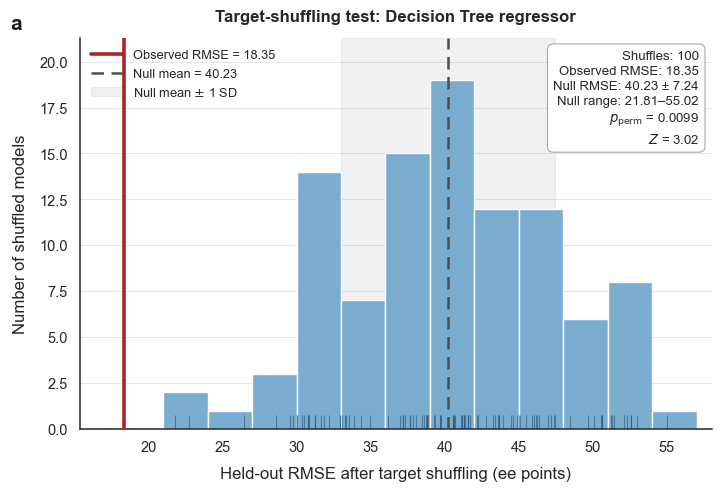

In [4]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# -------------------------
# Publication-style settings
# -------------------------
sns.set_theme(style="white", context="paper")

mpl.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 9.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "axes.linewidth": 1.1,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 4.5,
    "ytick.major.size": 4.5,
})

COLORS = {
    "histogram": "#74A9CF",
    "histogram_edge": "#2B6C9D",
    "rug": "#1F4E79",
    "observed": "#B22222",
    "null_mean": "#4D4D4D",
    "grid": "#E6E6E6",
    "text": "#1A1A1A",
}

# -------------------------
# Load input files
# -------------------------
shuffle_dist = pd.read_csv(SHUFFLE_DIST_FILE)
shuffle_summary = pd.read_csv(SHUFFLE_SUMMARY_FILE).iloc[0]

observed_rmse = float(shuffle_summary["observed_RMSE"])
null_mean = float(shuffle_summary["null_RMSE_mean"])
null_std = float(shuffle_summary["null_RMSE_std"])
null_min = float(shuffle_summary["null_RMSE_min"])
null_max = float(shuffle_summary["null_RMSE_max"])
p_value = float(shuffle_summary["empirical_one_sided_permutation_p"])
z_score = float(shuffle_summary["z_score"])
n_shuffles = int(shuffle_summary["n_shuffles"])

shuffle_rmse = pd.to_numeric(
    shuffle_dist["RMSE"],
    errors="coerce",
).dropna()

# -------------------------
# Use fixed, readable bins
# -------------------------
bin_width = 3.0
bin_start = np.floor(shuffle_rmse.min() / bin_width) * bin_width
bin_stop = np.ceil(shuffle_rmse.max() / bin_width) * bin_width + bin_width
bins = np.arange(bin_start, bin_stop, bin_width)

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(
    figsize=(7.1, 4.8),
    constrained_layout=True,
)

ax.hist(
    shuffle_rmse,
    bins=bins,
    color=COLORS["histogram"],
    edgecolor="white",
    linewidth=1.0,
    alpha=0.95,
    zorder=2,
)

# Small vertical marks show every shuffled RMSE outcome.
sns.rugplot(
    shuffle_rmse,
    height=0.035,
    color=COLORS["rug"],
    alpha=0.55,
    linewidth=0.8,
    ax=ax,
)

# Observed performance: lower RMSE is better.
ax.axvline(
    observed_rmse,
    color=COLORS["observed"],
    linewidth=2.6,
    zorder=5,
    label=f"Observed RMSE = {observed_rmse:.2f}",
)

# Center of empirical null distribution.
ax.axvline(
    null_mean,
    color=COLORS["null_mean"],
    linestyle=(0, (5, 3)),
    linewidth=1.8,
    zorder=4,
    label=f"Null mean = {null_mean:.2f}",
)

# Shaded null mean ± 1 SD is optional but readable.
ax.axvspan(
    null_mean - null_std,
    null_mean + null_std,
    color=COLORS["null_mean"],
    alpha=0.08,
    zorder=1,
    label=r"Null mean $\pm$ 1 SD",
)

# Panel label.
ax.text(
    -0.11,
    1.06,
    "a",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
    va="top",
    ha="left",
    color=COLORS["text"],
)

ax.set_title(
    "Target-shuffling test: Decision Tree regressor",
    fontweight="bold",
    pad=12,
)

ax.set_xlabel(
    "Held-out RMSE after target shuffling (ee points)",
    labelpad=8,
)

ax.set_ylabel(
    "Number of shuffled models",
    labelpad=8,
)

# Keep the observed line visible even though it lies left of the null distribution.
x_left = min(observed_rmse, shuffle_rmse.min()) - 3.0
x_right = shuffle_rmse.max() + 3.0
ax.set_xlim(x_left, x_right)

# Add statistics box.
stats_text = (
    f"Shuffles: {n_shuffles}\n"
    f"Observed RMSE: {observed_rmse:.2f}\n"
    f"Null RMSE: {null_mean:.2f} ± {null_std:.2f}\n"
    f"Null range: {null_min:.2f}–{null_max:.2f}\n"
    rf"$p_{{\mathrm{{perm}}}}$ = {p_value:.4f}" "\n"
    rf"$Z$ = {z_score:.2f}"
)

ax.text(
    0.98,
    0.97,
    stats_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9.5,
    linespacing=1.35,
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="white",
        edgecolor="#A6A6A6",
        linewidth=0.8,
        alpha=0.97,
    ),
    zorder=6,
)

ax.tick_params(
    direction="out",
    width=1.0,
    length=4.5,
    pad=4,
)

ax.yaxis.grid(
    True,
    color=COLORS["grid"],
    linewidth=0.75,
    zorder=0,
)

ax.xaxis.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="upper left",
    fontsize=9.2,
    handlelength=2.5,
)

fig.savefig(
    OUT_DIR / "Fig_S2_target_shuffling_DecisionTree_publication.pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUT_DIR / "Fig_S2_target_shuffling_DecisionTree_publication.svg",
    bbox_inches="tight",
)

fig.savefig(
    OUT_DIR / "Fig_S2_target_shuffling_DecisionTree_publication.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()